# Citation
Sravan Pannala et al "Consistently Tuned Battery Lifetime Predictive Model of Capacity Loss, Resistance Increase, and Irreversible Thickness Growth" J. Electrochem. Soc. 171 010532 (2024)  
Section: Degradation Model Tuning Process

In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dfols
from scipy import interpolate
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns_original import *
import pickle
plt.rcParams = set_rc_params(plt.rcParams)

eSOH_DIR = "./data/"
oCV_DIR = "./data/"

ModuleNotFoundError: No module named 'batfuns_original'

In [ ]:
# get parameter values
parameter_values = get_parameter_values()
# define model
spm = pybamm.lithium_ion.SPM(
    {
        "SEI": "ec reaction limited",
        "loss of active material": "stress-driven",
        "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
    }
)
# model internal parameters
param=spm.param
# define length of 1 cycle as 1 day i.e. 24 hours
calendar_time = 24
# initial conditions for ksei, Dsei, Ea,sei
ic= [1.5e-16, 2e-18, 10000]

## Tuning

In [ ]:
# define the cost function using the vector of data to be fitted
def multi_objective(model, data):
    """
    Generates cost function from model and data

    Equation 48,51,52 in paper

    Args:
        model : aging simulation solution output
        data : aging eSOH data

    Returns:
        weighted cost for different variables separately at all RPTs
    """    
    days = np.floor(data["Time"])
    # Y_cal
    variables = ["Capacity [A.h]", "n_Li","y_0","x_100"]
    # weights
    weights = [1/5,5,1,1]
    return np.concatenate([
        (np.array(model.loc[days][var]) - np.array(data[var])) * w
        for w,var in zip(weights,variables)
    ]
    )

# code to simulate lifetime aging
def simulate(x,eps_n_data,eps_p_data,SOC_0,Temp,experiment):
    """
    simulates aging given variables in a solver iteration

     Equation 50 in paper

    Args:
        x: vector of variables for a solver iteration
        eps_n_data : negative electrode active material ratio
        eps_p_data : positive electrode active material ratio
        SOC_0 : intital SOC
        Temp : Temperature
        experiment : Aging experiment for the cell

    Returns:
        dictionary of aging simulation solution outputs
    """    
    parameter_values.update(
        {   
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM constant proportional term [s-1]": 0,
            "Negative electrode LAM constant proportional term [s-1]": 0,
            "Positive electrode LAM constant proportional term 2 [s-1]": 0,
            "Negative electrode LAM constant proportional term 2 [s-1]": 0,
            "Positive electrode LAM constant exponential term": 1,
            "Negative electrode LAM constant exponential term": 1,
            "Lithium plating kinetic rate constant [m.s-1]": 0,
            "Li plating resistivity [Ohm.m]": 0,
            "SEI kinetic rate constant [m.s-1]": x[0] * ic[0],
            "EC diffusivity [m2.s-1]": x[1] * ic[1],
            "SEI growth activation energy [J.mol-1]": x[2] * ic[2],
            "SEI resistivity [Ohm.m]": 30000.0,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
            "Negative electrode partial molar volume [m3.mol-1]": 7e-06,

        },
        check_already_exists=False,
    )
    return cycle_adaptive_simulation_V2(spm, parameter_values, experiment,SOC_0,save_at_cycles=1)

# function to generate the prediction error
def prediction_error(x):
    """
    Generates the prediction error for a solver iteration
    Args:
        x : vector of variables for a solver iteration

    Returns:
        predict error used in solver
    """    
    try:
        out=[]
        # cell 22: Hot Temp (45C) Calendar Aging @ 100% SOC
        # cell 24: Cold Temp (-5C) Calendar Aging @ 100% SOC
        for cell in [22,24]:
            # load the data for each cell
            cell_no,dfe,N,dfo_0 = load_data_calendar(cell,eSOH_DIR,oCV_DIR)
            # get parameters to intialize the model
            eps_n_data,eps_p_data,SOC_0,Temp = init_exp_calendar(cell_no,dfe,param,parameter_values)
            # define the calendar aging experiment
            experiment = pybamm.Experiment(
                [
                    ("Rest for "+f'{calendar_time}'+" hours",)
                ]*int(N[-1]+10) ,
                termination="50% capacity",
            #     cccv_handling="ode",
            )
            # simulate the model
            model = simulate(x,eps_n_data,eps_p_data,SOC_0,Temp,experiment)
            # generate the error using cost function
            out_t =   multi_objective(pd.DataFrame(model), dfe)
            # concatenate the error for two cells
            out=np.concatenate([out,out_t])
        print(f"x={x}, norm={np.linalg.norm(out)}")
    except Exception as error:
        # error handling
        print(error)
        out=[]
        for cell in [22,24]:
            cell_no,dfe,N,dfo_0 = load_data_calendar(cell,eSOH_DIR,oCV_DIR)
            out_t = np.concatenate([np.array(dfe['Cap'])]*4)
            out=np.concatenate([out,out_t])
        out = 2*np.ones_like(out)
        print(f"x={x}, norm={np.linalg.norm(out)}")
    return out

In [17]:
# initial guess
x0 = np.array([1,1,1])
# lower bound
lower = np.array([1e-3, 1e-3, 1e-3])
# upper bound
upper = np.array([1e+3, 1e+3, 1e+3])
# run tuning
soln_dfols = dfols.solve(prediction_error, x0,bounds=(lower, upper), rhoend=1e-2) #rhoend=1e-4

<built-in function Function_call> returned a result with an error set
x=[1. 1. 1.], norm=14.422205101855956


In [10]:
# extract solution
x = soln_dfols.x
# multiply back the initial condition to the solution
x1 = np.multiply(ic,x)
# export to dataframe
df_x = pd.DataFrame(columns=['x_0','x_1','x_2','obj'], index=[0])
df_x['x_0'][0]= x1[0]
df_x['x_1'][0]= x1[1]
df_x['x_2'][0]= x1[2]
df_x['obj'][0]= np.linalg.norm(prediction_error(x))
# save results
df_x.to_csv("step_1_results.csv")

x=[1.46497638 0.80492304 1.13825127], norm=0.7105124604197568


## Simulate Results to Verify

In [11]:
# Plotting function
def plotc(all_sumvars_dict1,all_sumvars_dict2,esoh_data,esoh_data_2,leg1="sim1",leg2="sim2"):
    """
    Generates plot comparing simulation and data for two cells    

    Args:
        all_sumvars_dict1 : dictionary of aging simulation outputs for 1st cell
        all_sumvars_dict2 : dictionary of aging simulation outputs for 2nd cell 
        esoh_data : dataframe of eSOH data for 1st cell
        esoh_data_2 : dataframe of eSOH data for 2nd cell
        leg1 : description of 1st cell
        leg2 : description of 2nd cell

    Returns:
        plot
    """    
    esoh_vars = ["x_100", "y_0", "C_n", "C_p", "Capacity [A.h]", "Loss of lithium inventory [%]"]
    fig, axes = plt.subplots(3,2,figsize=(7,7))
    for k, name in enumerate(esoh_vars):
        ax = axes.flat[k]
        ax.plot(all_sumvars_dict1["Cycle number"],all_sumvars_dict1[name],"r^")
        ax.plot(esoh_data["N"],esoh_data[name],"kx")
        ax.plot(all_sumvars_dict2["Cycle number"],all_sumvars_dict2[name],"bv")
        ax.plot(esoh_data_2["N"],esoh_data_2[name],"kx")
        ax.set_title(split_long_string(name))
        if k ==2 or k==3:
            ax.set_ylim([5,6.2])
        if k>3:
            ax.set_xlabel("Days")
    fig.legend([leg1, "Data", leg2 ], 
           loc="lower center",bbox_to_anchor=[0.5,-0.05], ncol=1, fontsize=11)
    fig.tight_layout()
    return fig

In [12]:
sol = {}
esoh_data = {}
i = 0
# cell 22: Hot Temp (45C) Calendar Aging @ 100% SOC
# cell 24: Cold Temp (-5C) Calendar Aging @ 100% SOC
for cell in [22,24]:
    # load the data for each cell
    cell_no,dfe,N,dfo_0 = load_data_calendar(cell,eSOH_DIR,oCV_DIR)
    esoh_data[i]=dfe
    # get parameters to intialize the model
    eps_n_data,eps_p_data,SOC_0,Temp = init_exp_calendar(cell_no,dfe,param,parameter_values)
    # define the calendar aging experiment
    experiment = pybamm.Experiment(
        [
            ("Rest for "+f'{calendar_time}'+" hours",)
        ]*int(N[-1]+10) ,
        termination="50% capacity",
    #     cccv_handling="ode",
    )
    # simulate the model
    sol[i] = simulate(x,eps_n_data,eps_p_data,SOC_0,Temp,experiment)
    i+=1

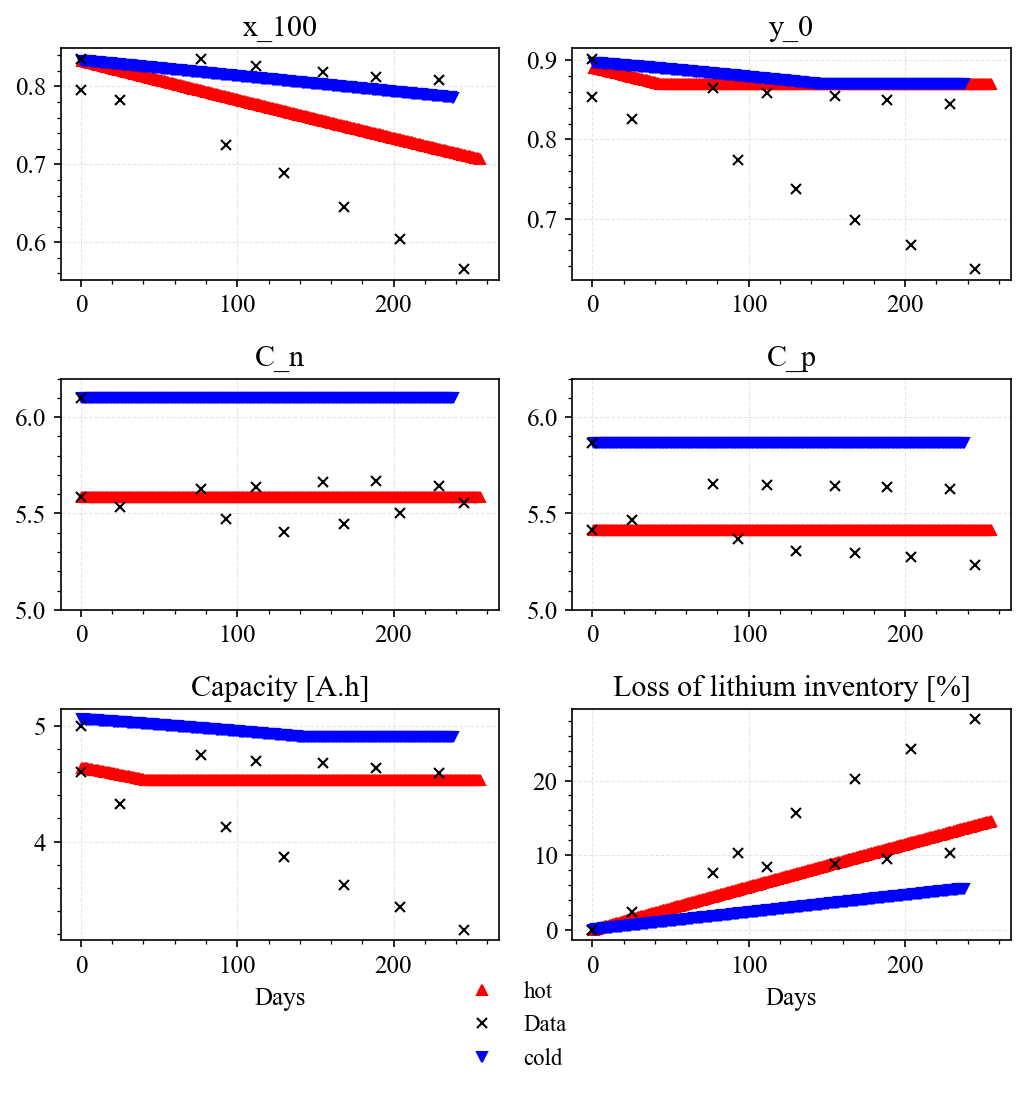

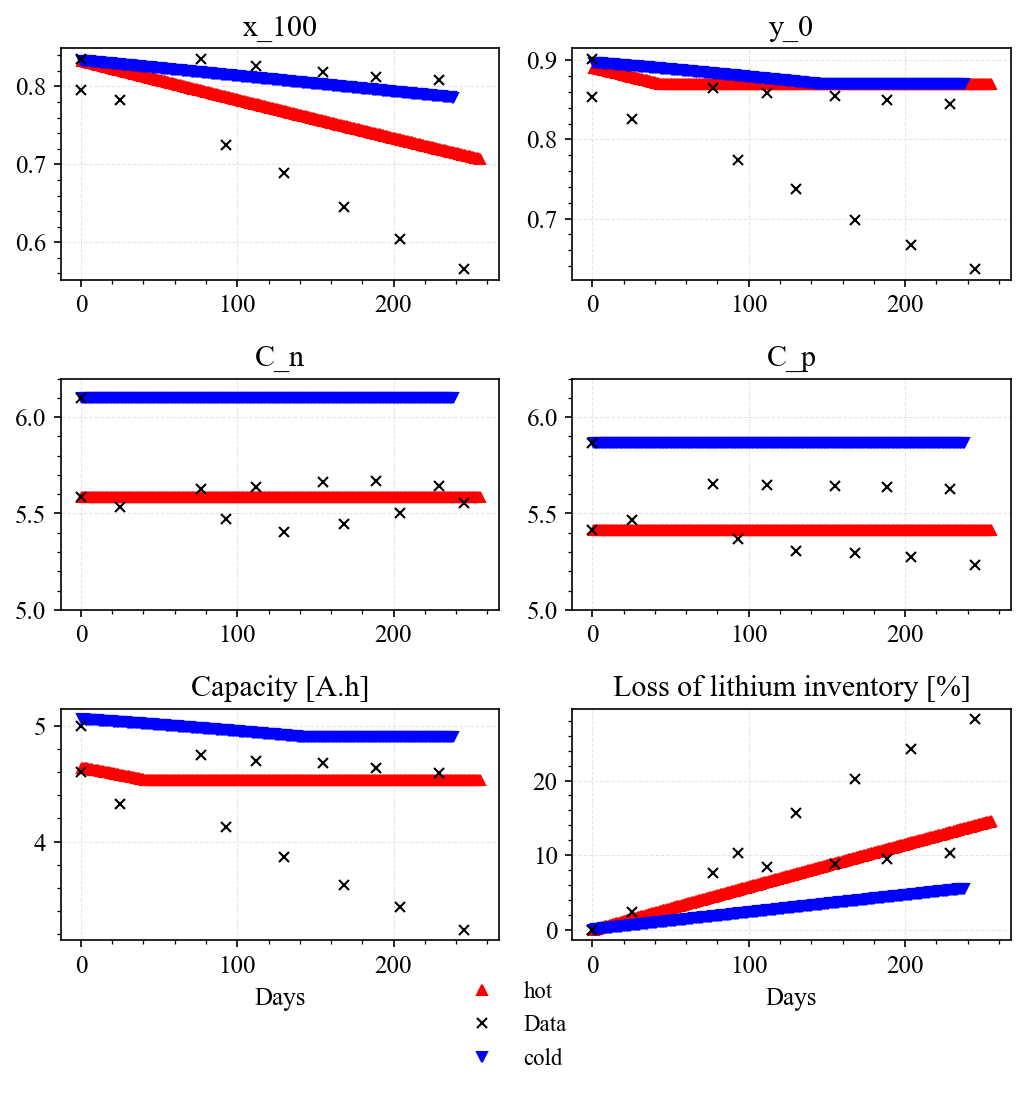

In [13]:
# plot tuning results
# plot hot and cold data and simulations together
plotc(sol[0],sol[1],esoh_data[0],esoh_data[1],leg1="hot",leg2="cold")